   Study_Hours  Attendance  Internal_Marks  Final_Marks
0            7          61               6         62.3
1            4          83               9         55.4
2            8          82               5         72.1
3            5          97               5         63.6
4            7          72              23         87.1
       Study_Hours  Attendance  Internal_Marks  Final_Marks
count   100.000000  100.000000      100.000000   100.000000
mean      5.910000   76.710000       14.170000    73.148000
std       2.871296   14.931016        6.742081    16.961969
min       1.000000   50.000000        5.000000    26.700000
25%       3.000000   63.750000        8.000000    62.100000
50%       6.000000   78.500000       13.000000    73.100000
75%       8.000000   88.000000       20.000000    84.525000
max      10.000000  100.000000       25.000000   110.900000
                Study_Hours  Attendance  Internal_Marks  Final_Marks
Study_Hours        1.000000    0.035434       -0.154172

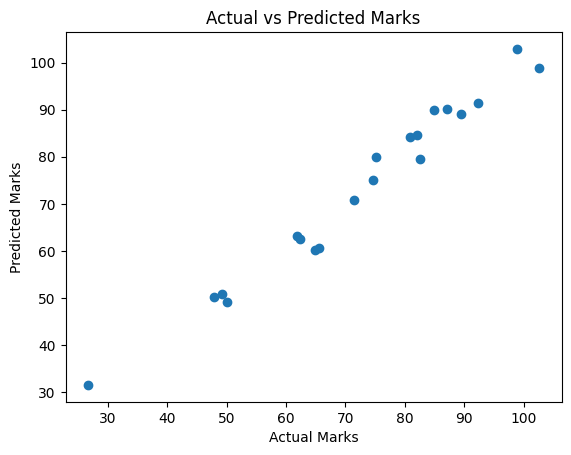

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
np.random.seed(42)

study_hours = np.random.randint(1, 11, 100)
attendance = np.random.randint(50, 101, 100)
internal_marks = np.random.randint(5, 26, 100)

final_marks = (study_hours * 5) + (attendance * 0.3) + (internal_marks * 1.5) + np.random.randint(-5,5,100)

df = pd.DataFrame({
    'Study_Hours': study_hours,
    'Attendance': attendance,
    'Internal_Marks': internal_marks,
    'Final_Marks': final_marks
})
print(df.head())
print(df.describe())
print(df.corr())
X = df[['Study_Hours', 'Attendance', 'Internal_Marks']]
y = df['Final_Marks']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Predicted Marks:", y_pred)
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)
new_student = pd.DataFrame([[6, 85, 18]],
                           columns=['Study_Hours', 'Attendance', 'Internal_Marks'])

prediction = model.predict(new_student)
print("Predicted Final Marks:", prediction)
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted Marks")
plt.show()